In [1]:
!pip install xgboost shap

In [3]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

import shap
import matplotlib.pyplot as plt

In [4]:
from google.colab import files
uploaded = files.upload()

df = pd.read_csv(list(uploaded.keys())[0])
df.head()

Saving dataset.csv to dataset (1).csv


,State,Crop,Soil_Type,Fertilizer,N,P,K,Rainfall_mm,Temperature_C,Yield_kg_per_acre,Soil_pH,Year
0,Karnataka,Soybean,Loamy,DAP,96,41,51,123,31.06,1899,6.82,2003
1,Odisha,Cotton,Red Soil,Urea,29,36,112,247,33.97,1002,6.41,2002
2,Punjab,Groundnut,Red Soil,Compost,37,38,177,142,24.21,1465,7.06,2015
3,Gujarat,Wheat,Red Soil,Compost,58,77,129,227,30.85,2273,5.93,2022
4,Andhra Pradesh,Cotton,Clay,Organic,108,61,63,263,37.81,1497,6.24,2017


In [6]:
# Replace 'target' with your actual target column name
target_column = 'Yield_kg_per_acre'

X = df.drop(columns=[target_column])
y = df[target_column]

# Convert categorical to numeric
X = pd.get_dummies(X, drop_first=True)

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [7]:
models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "XGBoost": XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
}

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    results[name] = {"RMSE": rmse, "MAE": mae, "R2": r2}

    print(f"\n{name}")
    print(f"RMSE: {rmse}")
    print(f"MAE: {mae}")
    print(f"R2 Score: {r2}")


Linear Regression
RMSE: 2799.705366814042
MAE: 1135.2386972537854
R2 Score: 0.9760011457922841

Random Forest
RMSE: 2685.6497033878045
MAE: 953.7447666666668
R2 Score: 0.9779166691308869

XGBoost
RMSE: 2790.051791633983
MAE: 993.5675048828125
R2 Score: 0.9761663675308228


In [8]:
results_df = pd.DataFrame(results).T
results_df.sort_values(by="R2", ascending=False)

,RMSE,MAE,R2
Random Forest,2685.649703,953.744767,0.977917
XGBoost,2790.051792,993.567505,0.976166
Linear Regression,2799.705367,1135.238697,0.976001


In [9]:
best_model_name = results_df["R2"].idxmax()
best_model = models[best_model_name]

print("Best Model:", best_model_name)

Best Model: Random Forest


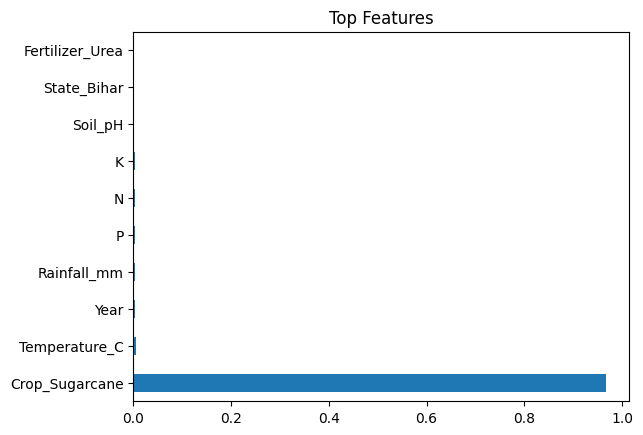

In [10]:
if best_model_name in ["Random Forest", "XGBoost"]:
    importances = best_model.feature_importances_
    feature_names = X.columns

    feat_imp = pd.Series(importances, index=feature_names)
    feat_imp.sort_values(ascending=False).head(10).plot(kind='barh')
    plt.title("Top Features")
    plt.show()

 99%|===================| 297/300 [00:12<00:00]       

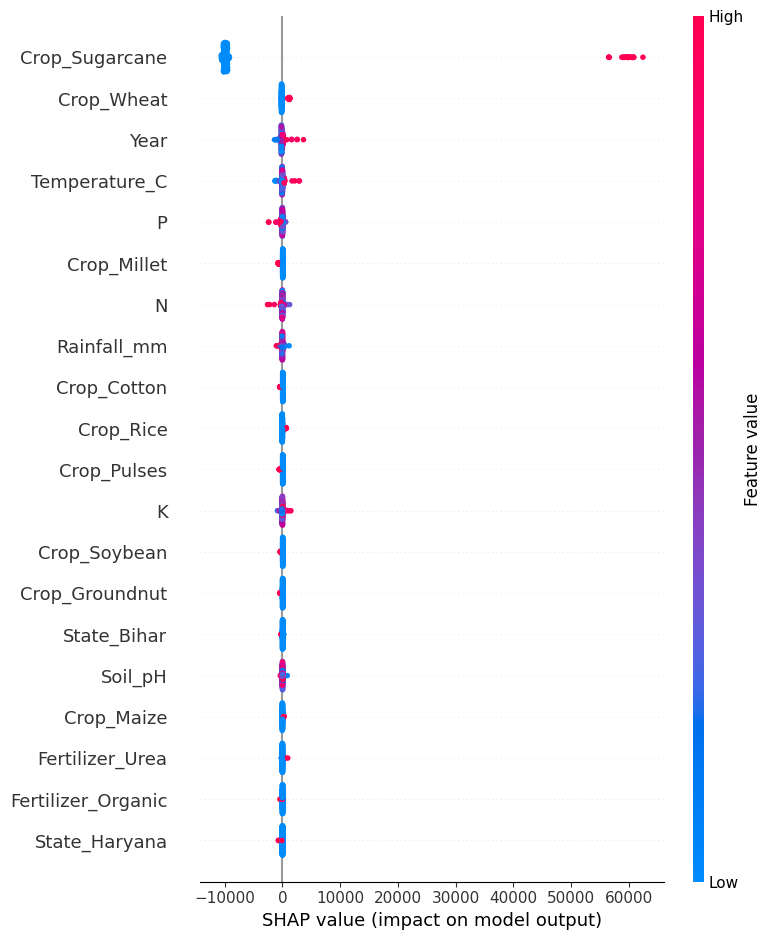

In [16]:
explainer = shap.Explainer(best_model, X_train.astype(float))
shap_values = explainer(X_test.astype(float))

shap.summary_plot(shap_values, X_test.astype(float))